**Crea una clave usuario:nombre con tu nombre.**

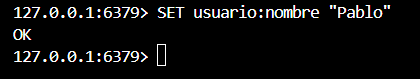

**Crea una clave usuario:apellido con tu apellido.**

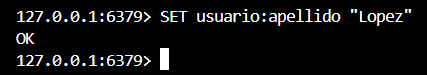


**Recupera el valor de ambas claves con GET.**

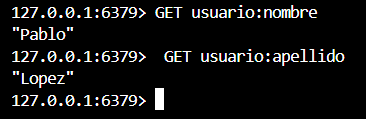

**Almacena en usuario:email un correo ficticio y recupéralo.**

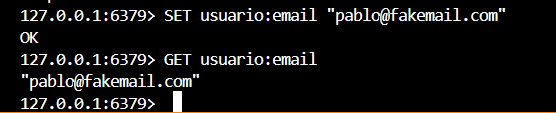


**Cambia el valor de usuario:nombre para que aparezca en mayúsculas.**

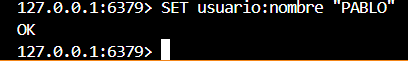

**Crea la clave contador:visitas con valor 0.**

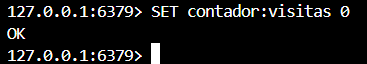

**Incrementa en 1 el valor de contador:visitas tres veces.**

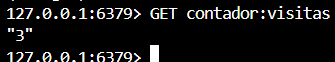

**Decrementa en 1 el valor de contador:visitas.**

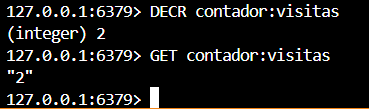

**Guarda en la clave mensaje el texto "Bienvenido a Redis".**

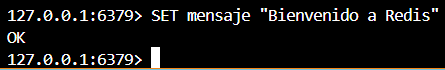

**Establece un tiempo de expiración de 60 segundos para la clave mensaje.**

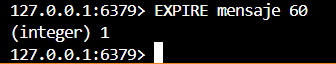

**Elimina la clave usuario:apellido.**

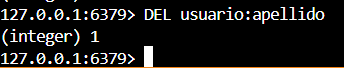

**Elimina el resto de claves que hayas creado**

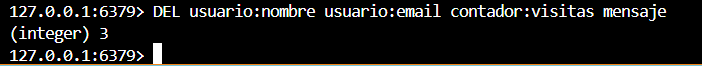




**Configuración e Inicialización**

In [3]:
import redis
import time # Necesario para esperar la expiración

# Asegúrate de reemplazar 'localhost' si tu contenedor Redis no es accesible
# en esa dirección (e.g., usa el nombre del servicio si estás en Docker Compose)
try:
    r = redis.Redis(host='localhost', port=6379, decode_responses=True)
    r.ping()
    print("Conexión a Redis exitosa.")
except Exception as e:
    print(f"Error de conexión a Redis: {e}")


Conexión a Redis exitosa.


**Creamos las claves**

In [4]:
# Inserta la clave app:version con el valor "1.0"
r.set('app:version', '1.0')
print(f"1. Valor inicial de app:version: {r.get('app:version')}")

# Modifica el valor de app:version a "1.1"
r.set('app:version', '1.1')
print(f"2. Nuevo valor de app:version: {r.get('app:version')}")

# Inserta la clave app:estado con el valor "activo"
r.set('app:estado', 'activo')
print(f"3. Valor inicial de app:estado: {r.get('app:estado')}")

# Cambia el valor de app:estado a "mantenimiento"
r.set('app:estado', 'mantenimiento')
print(f"4. Nuevo valor de app:estado: {r.get('app:estado')}")

# Inserta la clave mensaje:bienvenida con el texto "Hola alumno"
r.set('mensaje:bienvenida', 'Hola alumno')
print(f"5. Mensaje de bienvenida: {r.get('mensaje:bienvenida')}")

1. Valor inicial de app:version: 1.0
2. Nuevo valor de app:version: 1.1
3. Valor inicial de app:estado: activo
4. Nuevo valor de app:estado: mantenimiento
5. Mensaje de bienvenida: Hola alumno


**Contadores**

In [5]:
# Crea la clave contador:descargas con valor 0
r.set('contador:descargas', 0)
print(f"1. Valor inicial de contador:descargas: {r.get('contador:descargas')}")

# Incrementa en 5 el valor de contador:descargas
r.incrby('contador:descargas', 5)
print(f"2. Valor después de +5: {r.get('contador:descargas')}")

# Decrementa en 2 el valor de contador:descargas
r.decrby('contador:descargas', 2)
print(f"3. Valor después de -2: {r.get('contador:descargas')}")

1. Valor inicial de contador:descargas: 0
2. Valor después de +5: 5
3. Valor después de -2: 3


**app:estado**

In [9]:
# 1. Insertar la clave app:estado con el valor "activo"
r.set("app:estado", "activo")
print("1) app:estado =", r.get("app:estado"))

# 2. Cambiar el valor de app:estado a "mantenimiento"
r.set("app:estado", "mantenimiento")
print("2) app:estado cambiado a =", r.get("app:estado"))

# 3. Insertar la clave mensaje:bienvenida
r.set("mensaje:bienvenida", "Hola alumno")
print("3) mensaje:bienvenida =", r.get("mensaje:bienvenida"))

# 4. Establecer expiración de 30 segundos
r.expire("app:estado", 30)
print("4) Expiración de 30 segundos aplicada a app:estado")

# 5. Esperar unos segundos y comprobar si existe
time.sleep(5)
existe = r.exists("app:estado")
print("5) ¿Existe app:estado después de 5 segundos?:", "Sí" if existe else "No")

# 6. Esperar 30 segundos
time.sleep(30)
existe = r.exists("app:estado")
print("5) ¿Existe app:estado después de 30 segundos?:", "Sí" if existe else "No")


1) app:estado = activo
2) app:estado cambiado a = mantenimiento
3) mensaje:bienvenida = Hola alumno
4) Expiración de 30 segundos aplicada a app:estado
5) ¿Existe app:estado después de 5 segundos?: Sí
5) ¿Existe app:estado después de 30 segundos?: No


**Eliminar claves**

In [10]:
# Elimina la clave app:version
eliminado = r.delete('app:version')

# Muestra un mensaje confirmando su eliminación
if eliminado:
    print("La clave 'app:version' ha sido eliminada exitosamente.")
else:
    print("La clave 'app:version' no existía para ser eliminada.")
    
# Limpieza de claves restantes
r.delete('contador:descargas', 'mensaje:bienvenida')
print("\nLimpieza finalizada.")

La clave 'app:version' ha sido eliminada exitosamente.

Limpieza finalizada.
